In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')


In [4]:
df=pd.read_csv('Digital_Distraction.csv')
df.head(5)

,Age,Daily_Screen_Time,Social_Media_Time,Notifications,App_Switches,Sleep_Hours,Work_Hours,Distraction_Level
0,22,3.96,1.70,175,73,7.86,3.07,0
1,35,2.69,2.70,130,26,4.14,7.04,0
2,30,3.01,6.06,153,18,4.33,2.43,0
3,26,2.18,6.99,127,50,6.32,7.99,0
4,23,2.94,6.81,167,10,8.55,4.54,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                520 non-null    int64  
 1   Daily_Screen_Time  520 non-null    float64
 2   Social_Media_Time  520 non-null    float64
 3   Notifications      520 non-null    int64  
 4   App_Switches       520 non-null    int64  
 5   Sleep_Hours        520 non-null    float64
 6   Work_Hours         520 non-null    float64
 7   Distraction_Level  520 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 32.6 KB


In [6]:
df.isna().sum()

Age                  0
Daily_Screen_Time    0
Social_Media_Time    0
Notifications        0
App_Switches         0
Sleep_Hours          0
Work_Hours           0
Distraction_Level    0
dtype: int64

In [7]:
df.describe()

,Age,Daily_Screen_Time,Social_Media_Time,Notifications,App_Switches,Sleep_Hours,Work_Hours,Distraction_Level
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,27.238462,6.926192,4.546346,111.521154,63.907692,6.526212,5.969135,0.123077
std,7.339343,2.946760,2.067213,52.831462,32.400004,1.430256,2.353929,0.328842
min,16.000000,2.050000,1.040000,20.000000,10.000000,4.010000,2.000000,0.000000
25%,20.000000,4.247500,2.685000,65.750000,33.000000,5.400000,4.010000,0.000000
50%,27.000000,6.925000,4.625000,111.500000,64.500000,6.535000,5.945000,0.000000
75%,34.000000,9.512500,6.372500,160.000000,94.000000,7.770000,7.982500,0.000000
max,39.000000,12.000000,7.990000,199.000000,119.000000,8.990000,9.960000,1.000000


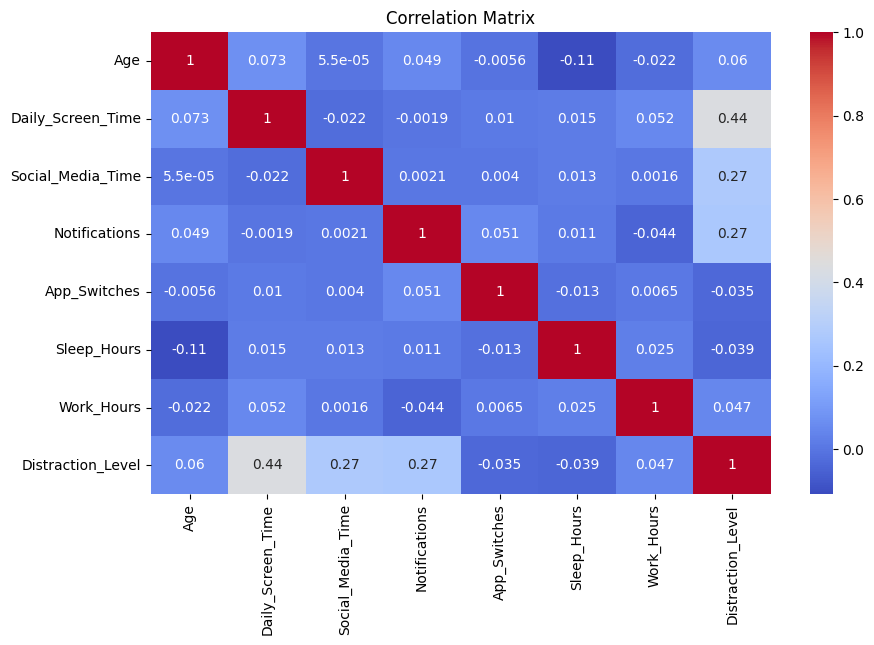

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [16]:
X=df.drop('Distraction_Level',axis=1)
Y=df['Distraction_Level']

In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler().set_output(transform='pandas')
X_pre=scaler.fit_transform(X)


In [18]:
import pickle
with open ('scaler.pkl','wb') as file1:
    pickle.dump(scaler,file1)

In [19]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=41)

In [20]:
xtrain.shape

(416, 7)

In [21]:
xtest.shape

(104, 7)

In [22]:
ytest.value_counts()

Distraction_Level
0    90
1    14
Name: count, dtype: int64

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
model=rf.fit(xtrain,ytrain)

In [24]:
model.score(xtrain,ytrain)

1.0

In [25]:
model.score(xtest,ytest)

0.9519230769230769

In [26]:
tr_pred=model.predict(xtrain)
ts_pred=model.predict(xtest)

In [27]:
tr_pred[:5]

array([0, 0, 0, 0, 0])

In [28]:
ytrain.head()

238    0
204    0
146    0
215    0
150    0
Name: Distraction_Level, dtype: int64

In [29]:
with open('model.pkl','wb') as file2:
    pickle.dump(model,file2)

In [30]:
with open('model.pkl','rb') as file4:
    m=pickle.load(file4)